In [4]:
#'block_size': 256,
#'n_embed': 384,
#'n_layers': 6,
#'n_heads': 6,

# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 128,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 2,
    "learning_rate": 3e-4,
    "max_steps": 500,
    #"dropout": 0.1,
    "layer_norm_enabled": True,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [5]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [ ]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
print("n_tokens", len(DATASET_TEXT))

In [7]:
with open("data/lotr.txt", "r", encoding="latin-1") as f: DATASET_TEXT = f.read()

In [8]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(89,
 ['\t',
  '\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  'Ó',
  'á',
  'â',
  'ä',
  'é',
  'ë',
  'í',
  'ó',
  'ú',
  'û'])

Create tokenizer:

In [9]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [10]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 1.4234,  1.0707, -1.1326,  ..., -0.6678,  2.0995, -1.5197],
         [ 1.4234,  1.0707, -1.1326,  ..., -0.6678,  2.0995, -1.5197],
         [ 1.4234,  1.0707, -1.1326,  ..., -0.6678,  2.0995, -1.5197],
         ...,
         [-0.7942, -0.9627, -1.7468,  ...,  0.7837,  1.1571,  1.6898],
         [-0.7942, -0.9627, -1.7468,  ...,  0.7837,  1.1571,  1.6898],
         [ 0.0515, -0.9960,  0.6738,  ..., -0.2322,  0.3747,  1.0101]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [11]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[ 0.4755, -0.3046,  0.2198,  ...,  0.6360, -1.6973,  1.6891],
         [-0.0298, -0.3999, -0.7935,  ..., -0.0635,  0.2037, -0.6532],
         [ 1.2005,  0.1497, -1.1224,  ..., -0.4143,  2.6629, -1.2042],
         ...,
         [ 0.9453,  1.4095, -1.1582,  ...,  1.9167, -0.5850,  1.1139],
         [ 0.7122, -0.0940,  0.4633,  ..., -1.0738, -0.6832,  1.2313],
         [ 0.1121, -0.5141, -1.3312,  ..., -0.0257, -1.6876,  1.2483]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [12]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[ 1.8989,  0.7661, -0.9129,  ..., -0.0318,  0.4022,  0.1694],
         [ 1.3936,  0.6708, -1.9261,  ..., -0.7313,  2.3032, -2.1729],
         [ 2.6240,  1.2204, -2.2550,  ..., -1.0821,  4.7624, -2.7239],
         ...,
         [ 0.1511,  0.4468, -2.9050,  ...,  2.7005,  0.5721,  2.8037],
         [-0.0820, -1.0567, -1.2835,  ..., -0.2901,  0.4738,  2.9211],
         [ 0.1636, -1.5101, -0.6574,  ..., -0.2580, -1.3129,  2.2584]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [13]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[70,  2, 40,  ..., 61, 66, 71],
         [ 2, 59, 67,  ..., 11,  2, 51],
         [ 4,  2, 71,  ..., 56,  2, 72],
         ...,
         [53, 74, 57,  ...,  2, 73, 66],
         [ 9,  2, 54,  ..., 66, 59,  2],
         [58,  2, 44,  ..., 53, 71,  2]]),
 torch.Size([10, 128]),
 tensor([[ 2, 40, 67,  ..., 66, 71,  2],
         [59, 67, 72,  ...,  2, 51, 67],
         [ 2, 71, 53,  ...,  2, 72, 67],
         ...,
         [74, 57,  2,  ..., 73, 66, 56],
         [ 2, 54, 57,  ..., 59,  2, 65],
         [ 2, 44, 61,  ..., 71,  2, 53]]))

Test decoding batch:

In [14]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: r Norbury as they called it, away north of the Shire. But there had been no king for nearly a thousand years, and even the ruins
y 0:  Norbury as they called it, away north of the Shire. But there had been no king for nearly a thousand years, and even the ruins 

x 1:  got the ring in your pocket," said the wizard.
	"Well, so I have!" cried Bilbo. "And my will and all the other documents too. Y
y 1: got the ring in your pocket," said the wizard.
	"Well, so I have!" cried Bilbo. "And my will and all the other documents too. Yo

x 2: " said Frodo.
	"Ah!" said Sam. "And where will they live? That's what I often wonder."
	***
	For a while the hobbits continued t
y 2:  said Frodo.
	"Ah!" said Sam. "And where will they live? That's what I often wonder."
	***
	For a while the hobbits continued to

x 3: en a cry that sounded like help, help! often repeated, ending with a last help! that trailed off into a long wail suddenly cut s
y 3: n a cry that sounded like help, help! often repeated, 

In [15]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([128, 128, 64]),
 tensor([ 1.0022, -0.5715, -0.1882,  2.8540,  0.2998,  1.0348,  0.8306, -0.2551,
          1.9186,  1.3989,  0.1650,  0.1547,  0.6533,  0.3299,  1.8351, -0.6717,
          0.4405, -0.7421, -1.2706,  0.4831, -2.8322, -0.8882, -0.4818,  1.4137,
         -1.0676,  0.7062, -1.1059,  0.5672, -0.6574,  2.4104,  0.0656,  1.3945,
         -1.4687,  0.5068, -2.6461,  0.8936, -3.1293,  1.9891, -2.7033,  0.1242,
          0.3563,  0.1171, -1.0588,  1.2506, -2.0918,  0.0887, -0.4824, -0.6798,
         -1.5041, -2.0658, -1.3434, -0.7114, -1.2821,  0.5037, -0.4031,  1.0266,
         -1.3684,  1.4759, -0.8359, -0.5582,  0.6341, -0.6814, -1.7169,  2.3993],
        grad_fn=<SelectBackward0>))

In [16]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [17]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]))

In [18]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([128, 64, 128])

In [19]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([128, 128, 128]),
 tensor([ 6.5912e+02,  2.9307e+01, -1.9378e+02, -7.2758e+01, -5.0151e+02,
         -1.7012e+03,  3.3631e+01, -1.0735e+03, -1.0696e+03,  4.3335e+02,
         -1.4580e+03, -2.7491e+02, -2.5976e+03, -8.9056e+02,  1.4813e+03,
         -6.4307e+02, -3.1356e+02, -7.7996e+02, -3.0532e+02, -3.3009e+02,
          2.1227e+03, -1.2055e+02,  3.3426e+02, -7.7232e+02,  2.1513e+03,
          3.6680e+01,  7.0467e+02, -4.2474e+02, -1.9118e+02, -1.2238e+03,
         -6.2863e+02, -1.6615e+03, -2.0664e+03,  1.5943e+02,  8.7083e+02,
          2.8748e+02, -1.4265e+03,  1.0179e+02, -8.9373e+02, -1.2888e+02,
          2.5226e+03,  6.6295e+02,  4.7999e-03, -7.7477e+02, -1.8776e+02,
         -1.1053e+03,  1.7054e+02,  1.3460e+02,  5.8059e+02, -9.9394e+02,
          1.6524e+02, -2.0351e+02, -5.4730e+02,  1.4766e+02, -4.9606e+02,
          9.1728e+02, -1.6438e+02, -2.9454e+02, -3.9579e+02, -9.7609e+02,
         -1.2803e+03,  7.7443e+01, -4.9778e+02, -1.6318e+02, -1.0741e+03,
        

In [20]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([128, 128, 128]),
 tensor([ 8.2390e+01,  3.6633e+00, -2.4222e+01, -9.0947e+00, -6.2688e+01,
         -2.1265e+02,  4.2039e+00, -1.3418e+02, -1.3369e+02,  5.4168e+01,
         -1.8225e+02, -3.4364e+01, -3.2470e+02, -1.1132e+02,  1.8516e+02,
         -8.0384e+01, -3.9195e+01, -9.7494e+01, -3.8165e+01, -4.1262e+01,
          2.6533e+02, -1.5068e+01,  4.1782e+01, -9.6541e+01,  2.6891e+02,
          4.5850e+00,  8.8084e+01, -5.3092e+01, -2.3897e+01, -1.5298e+02,
         -7.8578e+01, -2.0768e+02, -2.5830e+02,  1.9928e+01,  1.0885e+02,
          3.5935e+01, -1.7831e+02,  1.2724e+01, -1.1172e+02, -1.6110e+01,
          3.1533e+02,  8.2869e+01,  5.9999e-04, -9.6847e+01, -2.3469e+01,
         -1.3816e+02,  2.1318e+01,  1.6825e+01,  7.2574e+01, -1.2424e+02,
          2.0654e+01, -2.5439e+01, -6.8413e+01,  1.8458e+01, -6.2007e+01,
          1.1466e+02, -2.0547e+01, -3.6818e+01, -4.9473e+01, -1.2201e+02,
         -1.6004e+02,  9.6804e+00, -6.2222e+01, -2.0397e+01, -1.3426e+02,
        

In [21]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [22]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [23]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([128, 128, 128]),
 tensor([[  82.3903,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [-191.2885, -113.5314,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 318.3049,  172.0428,    5.0534,  ...,      -inf,      -inf,
               -inf],
         ...,
         [  53.1738,   63.9877,  -21.2972,  ...,  -55.5732,      -inf,
               -inf],
         [   9.3550,   -4.7708,  135.0918,  ...,   11.0167,  134.3605,
               -inf],
         [ 134.0296,   19.2236, -103.7863,  ..., -130.1009,   87.9738,
           -87.4170]], grad_fn=<SelectBackward0>))

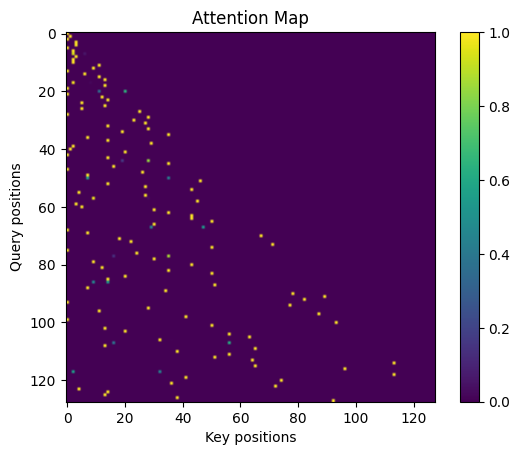

In [24]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [25]:
output = attention @ V
output.shape

torch.Size([128, 128, 64])

In [26]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([128, 128, 32]),
 tensor([[[ 0.0121, -1.1207, -0.7103,  ..., -2.4536,  0.6150, -0.6914],
          [-0.5631,  0.5207,  0.3175,  ..., -2.1291,  0.7384, -0.6036],
          [ 0.0121, -1.1207, -0.7103,  ..., -2.4536,  0.6150, -0.6914],
          ...,
          [ 0.4893,  0.0424,  1.7189,  ..., -0.1558,  1.1588, -1.4851],
          [-0.0169,  0.4576,  1.0492,  ...,  0.4973,  0.9119, -1.2226],
          [ 0.7530,  0.5848, -1.8384,  ..., -1.6591, -1.4004, -0.8842]],
 
         [[ 0.0048, -0.3829, -1.2313,  ..., -1.9282,  1.1485, -0.8175],
          [-0.0803,  0.1269,  2.4246,  ..., -0.4736,  0.6455, -1.5453],
          [ 0.0048, -0.3829, -1.2313,  ..., -1.9282,  1.1485, -0.8175],
          ...,
          [ 2.7147,  3.1214, -0.1476,  ..., -0.1028,  1.4566, -1.3964],
          [ 0.7561,  1.4896, -0.5807,  ..., -1.9913,  1.5122, -0.2984],
          [ 0.0491, -0.1459,  0.0841,  ..., -0.7745,  0.2151, -0.2539]],
 
         [[-0.8828, -0.0561, -0.5688,  ..., -2.2964,  1.6279, -1.2256],

In [27]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        self.W_q = nn.Linear(embed_size, head_size)
        self.W_k = nn.Linear(embed_size, head_size)
        self.W_v = nn.Linear(embed_size, head_size)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[ 4.3401e-01,  1.1291e+00, -2.1154e-02],
          [ 3.6062e-01,  1.4651e+00, -7.1931e-03],
          [ 3.4397e-01,  1.0819e+00,  1.9495e-01],
          [ 2.2395e-01,  7.0480e-01,  1.7406e-01],
          [ 4.6249e-01,  6.6591e-01,  1.1805e-02],
          [ 1.8415e-01,  6.1226e-01, -1.2267e-01],
          [ 2.9571e-01,  8.9388e-01, -3.7235e-02],
          [-2.7191e-02,  5.9799e-01, -8.7659e-02],
          [-2.1953e-03,  6.9600e-01, -1.1233e-01],
          [ 1.2278e-01,  7.5494e-01, -9.2786e-02],
          [-2.0837e-02,  6.2266e-01, -2.3141e-01],
          [ 1.4680e-02,  6.7663e-01, -1.3918e-01],
          [-1.0667e-01,  4.8933e-01, -2.3589e-01],
          [-2.1077e-01,  5.1689e-01, -2.2467e-01],
          [-1.5246e-01,  5.7765e-01, -1.9836e-01],
          [-1.2347e-01,  5.7996e-01, -1.6590e-01],
          [-1.4762e-01,  5.2075e-01, -1.6751e-01],
          [-2.5907e-01,  3.9039e-01, -2.5915e-01],
          [-2.1906e-01,  5.2390e-01, -2.0969e-01],
     

In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.5686, -0.0716, -0.0020,  ..., -0.3196,  0.0337, -0.2940],
          [-0.4662, -0.0279, -0.0751,  ..., -0.4040,  0.2462, -0.1891],
          [-0.4805, -0.0115,  0.0156,  ..., -0.3371,  0.1583, -0.1246],
          ...,
          [-0.0792,  0.0469, -0.0090,  ..., -0.1379,  0.1188,  0.1535],
          [-0.1305,  0.0668, -0.0162,  ..., -0.1169,  0.1186,  0.1373],
          [-0.1456,  0.0560, -0.0006,  ..., -0.1017,  0.1021,  0.1387]]],
        grad_fn=<ViewBackward0>))

In [29]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.1091,  0.0055,  0.0498,  ..., -0.0488,  0.0552,  0.0617],
          [-0.0860,  0.0511,  0.0490,  ..., -0.0677,  0.0615, -0.0123],
          [-0.0925,  0.0376,  0.0493,  ..., -0.0597,  0.0605,  0.0113],
          ...,
          [-0.0756,  0.0072,  0.0367,  ..., -0.0428,  0.0114,  0.0492],
          [-0.0726,  0.0082,  0.0314,  ..., -0.0378,  0.0071,  0.0292],
          [-0.0718,  0.0025,  0.0354,  ..., -0.0358,  0.0096,  0.0363]]],
        grad_fn=<ViewBackward0>))

In [30]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = MultiHeadAttention()
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-1.5146,  0.1557, -0.0826,  ...,  0.8924,  0.9820, -0.3496],
          [-2.4527, -1.3290, -1.5669,  ..., -0.5261,  0.3550,  0.2709],
          [-0.1596, -0.7186, -0.7130,  ..., -0.5642,  0.3603,  1.2793],
          ...,
          [ 0.3312,  0.5148,  0.5095,  ..., -0.5681,  1.3055,  1.0142],
          [-0.3788,  0.5220, -1.0899,  ...,  2.0878, -1.3009, -0.6433],
          [ 1.5915,  0.9709, -0.8294,  ..., -0.5010,  2.5053, -1.4486]]],
        grad_fn=<AddBackward0>))

In [31]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 60, 57, 64,
         64, 67]])

In [32]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 89]),
 tensor([ 0.0548, -0.6845,  0.3984,  0.3301, -0.8581,  0.1863, -0.4627,  0.2837,
         -0.0880, -0.3277,  0.3801, -0.0296, -0.1437,  0.6947,  0.5671,  0.3594,
          0.9722, -0.3643,  0.9977,  0.1935, -0.5008,  0.3293, -0.2070,  0.1880,
          0.0209,  0.5793, -0.7435,  0.6764,  0.0099,  0.8898,  0.6180,  0.3276,
          0.7639, -0.4428,  1.4293,  0.3043,  0.0245,  0.9253, -0.4624, -0.4697,
         -0.6020,  0.3012,  0.6254, -0.8915,  0.1675, -0.5898, -0.4331, -0.6689,
         -0.4188,  0.7077, -0.1796,  0.1619, -0.1835, -0.9331,  0.9266, -0.1579,
         -0.0546,  0.6821, -0.0623,  0.5301,  0.3641,  0.4933, -0.0097,  0.3995,
         -1.9261,  0.2523, -0.8411,  0.4057, -0.7204,  0.3783,  0.1433,  0.1034,
          1.4861, -1.4279,  0.7532, -1.2681,  0.7791,  0.3844,  0.9293,  0.9822,
          0.1548, -0.5267,  0.1378, -0.2201, -0.3136,  0.3902,  0.0198, -0.5753,
          1.3934], grad_fn=<SelectBackward0>))

In [33]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:Lord Of Th
y:ord Of The


In [34]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x: have to s
y:have to si
---
x:g.
	"Well,
y:.
	"Well, 
---
x: time. His
y:time. His 
---
x:d at Frodo
y: at Frodo.
---
x:hatred and
y:atred and 
---
x:out to sea
y:ut to sea;
---
x: very stro
y:very stron
---
x:ed Frodo. 
y:d Frodo. "
---
x:which just
y:hich just 
---
x: begging y
y:begging yo
---


In [35]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(89, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (head): MultiHeadAttention(
        (heads): ModuleList(
          (0-1): 2 x AttentionHead(
            (W_q): Linear(in_features=64, out_features=32, bias=True)
            (W_k): Linear(in_features=64, out_features=32, bias=True)
            (W_v): Linear(in_features=64, out_features=32, bias=True)
          )
        )
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=89, bias=True)
  (ln_final): LayerNorm((

In [36]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

In [46]:
from tqdm import tqdm

#optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 5
losses = []
grad_norms = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        grad_norm = get_grad_norm(model)
        grad_norms.append(grad_norm)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.4f}")

Epoch 4/5:  45%|████▌     | 3544/7821 [03:12<03:51, 18.45it/s, grad_norm=1.3586, loss=1.2941]


KeyboardInterrupt: 

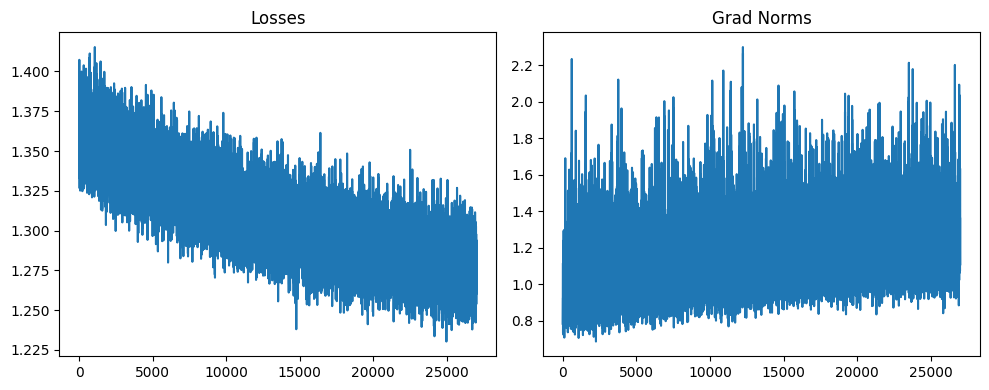

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [48]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

s, and the fear about in you pool. He was all!" pered Bill Nine of it mirror rumour happily, where days. Whethen he was drew frignified. "I onloking two just in anothers, adreading to the same crew is were above there tonight."
	"What all, too on that I feel know that their lit among that labour. It's nor paid on the escape from that the folkets," said Great peep over mered played the Yearly Aragorn. Rain or trees go by set a great branches. Othem there daylights. "So I am was a deep one on The Composs and entrangled by while thought," he souses. "I am am annous, and I has went outside you on it."
	"So I am not be remembes. But glowered now off of over of kind heard inclouded Frodo late, beyond the great hunting with a low fingers:
		Homisuit my they part Eaken; until there is light beyond it. Legolas shining events of read are force them-feel take off. Blue we have journey pack, they are inside Pippin; but give. And long coter long blindfort: him delay. If those that money off to do, 

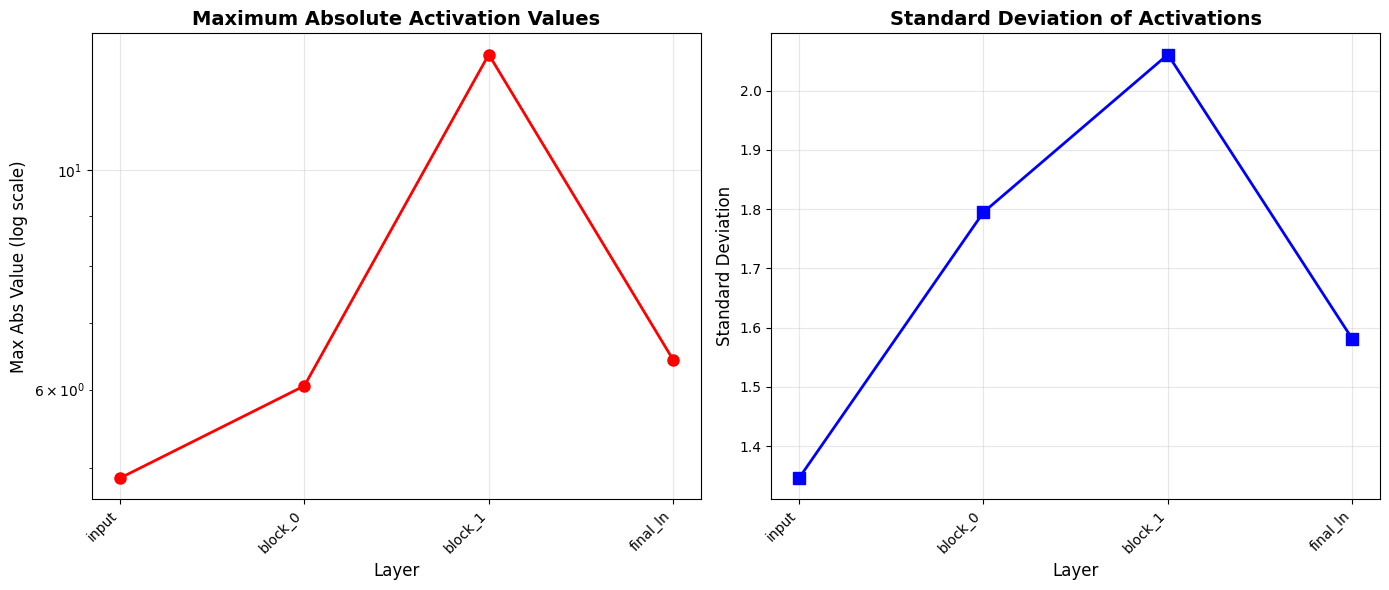


ACTIVATION STATISTICS
Layer                   Mean          Std      Max Abs
----------------------------------------------------------------------
input                -0.0064       1.3458       4.8813
block_0               0.0242       1.7945       6.0523
block_1              -0.0637       2.0609      13.0976
final_ln             -0.0149       1.5808       6.4289

Activation Growth Rate (Final/Initial): 1.32x
Initial max abs: 4.8813
Final max abs: 6.4289


In [40]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")